In [ ]:
!pip install pandas
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2020/avx512, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo/avx512, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2020/avx2, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo/avx2, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2020/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
  Using cached pandas-2.3.3-cp310-cp310-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
Processing /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic/pytz-2026.2+computecanada-py3-none-any.whl (from pandas)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 48.9 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]
Looking in indexes: https://download.pytorch.org/whl/cu124
Looking in links: /cvmfs/soft.computecanada.ca/

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import socket
print(socket.gethostname())
import torch
from torch import nn
from torch.utils.data import TensorDataset,DataLoader, Dataset
print("cuda available?", torch.cuda.is_available())
import scipy.linalg as linalg
import matplotlib.pyplot as plt
print(f"NumPy:  {np.__version__}")
print(f"PyTorch: {torch.__version__}")
import os
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")
output_dir = "/home/dtian/scratch/Di_Research/CNN_Weights/CNN_1.4/"

fc10604
cuda available? True
NumPy:  1.25.2
PyTorch: 2.6.0+cu124
Using cuda device


In [ ]:
!nvidia-smi
import os
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))

Tue Jul 14 00:48:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.03             Driver Version: 580.159.03     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          On  |   00000000:06:00.0 Off |                    0 |
| N/A   23C    P0             67W /  700W |       5MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
!ls -la /dev/nvidia*

crw-rw-rw- 1 root root 195,   0 Jun 17 13:32 /dev/nvidia0
crw-rw-rw- 1 root root 195,   1 Jun 17 13:32 /dev/nvidia1
crw-rw-rw- 1 root root 195,   2 Jun 17 13:32 /dev/nvidia2
crw-rw-rw- 1 root root 195,   3 Jun 17 13:32 /dev/nvidia3
crw-rw-rw- 1 root root 195, 255 Jun 17 13:32 /dev/nvidiactl
crw-rw-rw- 1 root root 195, 254 Jun 17 13:32 /dev/nvidia-modeset
crw-rw-rw- 1 root root 509,   0 Jun 17 13:33 /dev/nvidia-uvm
crw-rw-rw- 1 root root 509,   1 Jun 17 13:33 /dev/nvidia-uvm-tools

/dev/nvidia-caps:
total 0
drwxr-xr-x  2 root root     80 Jun 17 13:33 .
drwxr-xr-x 22 root root   3860 Jun 17 13:33 ..
cr--------  1 root root 234, 1 Jun 17 13:33 nvidia-cap1
cr--r--r--  1 root root 234, 2 Jun 17 13:33 nvidia-cap2


In [ ]:
import ctypes
cuda = ctypes.CDLL("libcuda.so.1")
result = cuda.cuInit(0)
print("cuInit result code:", result)   # 0 = success; anything else is the real error

cuInit result code: 0


In [ ]:
!systemctl is-active nvidia-fabricmanager

inactive


In [ ]:
!nvidia-smi topo -m


	GPU0	GPU1	NIC0	NIC1	NIC2	NIC3	NIC4	NIC5	CPU Affinity	NUMA Affinity	GPU NUMA ID
GPU0	 X 	NV6	SYS	SYS	SYS	SYS	PXB	PHB		3		N/A
GPU1	NV6	 X 	SYS	SYS	SYS	SYS	PHB	PXB		3		N/A
NIC0	SYS	SYS	 X 	PIX	SYS	SYS	SYS	SYS				
NIC1	SYS	SYS	PIX	 X 	SYS	SYS	SYS	SYS				
NIC2	SYS	SYS	SYS	SYS	 X 	PHB	SYS	SYS				
NIC3	SYS	SYS	SYS	SYS	PHB	 X 	SYS	SYS				
NIC4	PXB	PHB	SYS	SYS	SYS	SYS	 X 	PHB				
NIC5	PHB	PXB	SYS	SYS	SYS	SYS	PHB	 X 				

Legend:

  X    = Self
  SYS  = Connection traversing PCIe as well as the SMP interconnect between NUMA nodes (e.g., QPI/UPI)
  NODE = Connection traversing PCIe as well as the interconnect between PCIe Host Bridges within a NUMA node
  PHB  = Connection traversing PCIe as well as a PCIe Host Bridge (typically the CPU)
  PXB  = Connection traversing multiple PCIe bridges (without traversing the PCIe Host Bridge)
  PIX  = Connection traversing at most a single PCIe bridge
  NV#  = Connection traversing a bonded set of # NVLinks

NIC Legend:

  NIC0: mlx5_0
  NIC1: mlx5_1
  NIC2

In [ ]:
trans_scin_range = (0.01,0.2)
AGN_scin_range = (0.00005,0.2)  ## replicates the observed variability fractions in CHILES VERDES
varbins = np.array([0,0.02,0.1]) ## fractional brightness fluctuation standard deviation. 0.1 Corresponds to a 10% RMS flux density fluctuation
varprobs = np.array([136/185,33/185,16/185]) ## correspond probabilities. Must sum to 1

### LOAD IN THE VARIABILITY: ###

#scinlib = np.load('/Users/dtian/Documents/Programming/Di_Research/Di_codefromFir/scintillation_library.npz')['varlib']
scinlib = np.load('/home/dtian/scratch/Di_Research/Di_codefromFir/scintillation_library.npz')['varlib']
#varlib = np.load('/Users/dtian/Documents/Programming/Di_Research/Di_codefromFir/variation_library.npz')['varlib']
varlib = np.load('/home/dtian/scratch/Di_Research/Di_codefromFir/variation_library.npz')['varlib']

In [ ]:

#transientsdata = (np.load('/Users/dtian/Documents/Programming/Di_Research/Di_codefromFir/TDE_afterglows/ISM_profile/JettedTDE_ISM1.npz')['data'])[:,:,20]
transientsdata = (np.load('/home/dtian/scratch/Di_Research/Di_codefromFir/TDE_afterglows/ISM_profile/JettedTDE_ISM1.npz')['data'])[:,:,20]
transientsdata = np.append(transientsdata, (np.load('/home/dtian/scratch/Di_Research/Di_codefromFir/TDE_afterglows/wind_profile/JettedTDE_wind1.npz')['data'])[:,:,20], axis=0)
transientsdata = np.append(transientsdata, (np.load('/home/dtian/scratch/Di_Research/Di_codefromFir/TDE_afterglows/wind_profile/JettedTDE_wind2.npz')['data'])[:,:,20], axis=0)
transientsdata = np.append(transientsdata, (np.load('/home/dtian/scratch/Di_Research/Di_codefromFir/TDE_afterglows/wind_profile/JettedTDE_wind3.npz')['data'])[:,:,20], axis=0)
transientsdata = np.append(transientsdata, (np.load('/home/dtian/scratch/Di_Research/Di_codefromFir/GRB_afterglows/ISM_profile/GRB_ISM1.npz')['data'])[:,:,20], axis=0)
transientsdata = np.append(transientsdata, (np.load('/home/dtian/scratch/Di_Research/Di_codefromFir/GRB_afterglows/ISM_profile/GRB_ISM2.npz')['data'])[:,:,20], axis=0)
transientsdata = np.append(transientsdata, (np.load('/home/dtian/scratch/Di_Research/Di_codefromFir/GRB_afterglows/ISM_profile/GRB_ISM3.npz')['data'])[:,:,20], axis=0)
transientsdata = np.append(transientsdata, (np.load('/home/dtian/scratch/Di_Research/Di_codefromFir/GRB_afterglows/wind_profile/GRB_wind1.npz')['data'])[:,:,20], axis=0)
transientsdata = np.append(transientsdata, (np.load('/home/dtian/scratch/Di_Research/Di_codefromFir/GRB_afterglows/wind_profile/GRB_wind2.npz')['data'])[:,:,20], axis=0)
transientsdata = np.append(transientsdata, (np.load('/home/dtian/scratch/Di_Research/Di_codefromFir/GRB_afterglows/wind_profile/GRB_wind3.npz')['data'])[:,:,20], axis=0)
#transientsdata = np.append(transientsdata_1, transientsdata_2, transientsdata_3, transientsdata_4, transientsdata_5, transientsdata_6, transientsdata_7, transientsdata_8, transientsdata_9, transientsdata_10, axis=0)
print(transientsdata.shape) 


(70000, 608)


In [ ]:
def make_gaussian_heatmap(binary_target, sigma=2.0):
    """
    binary_target: (H, W) array with a few 1s at feature locations.
    returns:       (H, W) float heatmap, peaks = 1.0 at each feature.
    """
    H, W = binary_target.shape
    heatmap = np.zeros((H, W), dtype=np.float16) #changed from 32 originally

    # locations of the 1s
    ys, xs = np.nonzero(binary_target)

    # precompute kernel radius (3 sigma covers ~99% of the blob)
    radius = int(np.ceil(3 * sigma))

    for cy, cx in zip(ys, xs):
        # bounds of the patch to write into (clipped to image edges)
        y0, y1 = max(0, cy - radius), min(H, cy + radius + 1)
        x0, x1 = max(0, cx - radius), min(W, cx + radius + 1)

        yy, xx = np.mgrid[y0:y1, x0:x1]
        g = np.exp(-((yy - cy) ** 2 + (xx - cx) ** 2) / (2 * sigma ** 2))

        # max-combine so overlapping blobs stay <= 1
        heatmap[y0:y1, x0:x1] = np.maximum(heatmap[y0:y1, x0:x1], g)

    return heatmap

In [ ]:
def gaussian2d(x,y,meanx,meany):

    FWHM = 5

    '''
    returns a 2d gaussian with the right shape
    '''

    return np.exp(-0.5*2.3**2*((x-meanx)**2+(y-meany)**2)/FWHM**2) # factor of 2.3 converts the FWHM to a standard deviation

def genbackground(xlen,ylen,tlen,Nbgnd,noiseamp=0.1):

    x = np.arange(xlen) ## x,y,t arrays
    y = np.arange(ylen)
    t = np.arange(tlen) 

    xx,yy,tt = np.meshgrid(x,y,t) ## create a grid of x,y positions to evaluate at

    #np.random.seed(41)
    rng = np.random.default_rng(123)
    
    noisefield = noiseamp*rng.standard_normal(size = (xlen,ylen,tlen)) # generate the noise

    backgroundfield = np.zeros(noisefield.shape) ## array for the transient layer to be created in
    
    x0 = [] ## these record the x, y, and time mean values for each transient signal
    y0 = [] ## these record the x, y, and time mean values for each transient signal
    positions = np.zeros((Nbgnd,2))

    for i in range(Nbgnd): ## for each background source

        x0.append(np.random.randint(xlen)) 
        y0.append(np.random.randint(ylen)) ## generate a uniform random map position

        bgfluxdensity = 10**(2*np.random.rand()-1) ## brightness, right now log-uniform between 0.1 and 10

        layer = bgfluxdensity*gaussian2d(xx,yy,x0[-1],y0[-1]) # add the map layer value

        ## apply intrinsic variability:

        idx = np.random.randint(2000)
        phase = np.random.randint(608)

        randfloat = np.random.rand()
        
        if randfloat <= varprobs[0]:
            amp = varbins[0]
        elif randfloat <= varprobs[0]+varprobs[1]:
            amp = varbins[1]
        else:
            amp = varbins[2]
        
        layer*= 1+amp*(varlib[idx][phase:])[np.newaxis,np.newaxis,:tlen]

        ## apply extrinsic variability:

        idx = np.random.randint(2000)
        phase = np.random.randint(608)
        amp = 10**((np.log10(AGN_scin_range[1]/AGN_scin_range[0]))*np.random.rand()+np.log10(AGN_scin_range[0]))
        #print(amp)

        layer*= 1+amp*(varlib[idx][phase:])[np.newaxis,np.newaxis,:tlen]

        backgroundfield += layer



    positions[:,0] = np.array(x0)
    positions[:,1] = np.array(y0)

    return backgroundfield,noisefield,positions
        
def gentransients(xlen,ylen,tlen,Ntrans):
    '''
    Return  transient_field:    100*100*608 transient field
            positions:          Ntrans * 2 transient positions
            gaussian_transient_map 100*100 2d-gaussian position of the transient
    '''

    global transientsdata
    #np.random.seed(41)
    x = np.arange(xlen) ## x and y arrays
    y = np.arange(ylen)
    t = np.arange(tlen) 

    xx,yy,tt = np.meshgrid(x,y,t) ## create a grid of x,y positions to evaluate at

    transient_field = np.zeros((xlen,ylen,tlen)) ## array for the transient layer to be created in
    
    x0 = [] ## these record the x, y, and time mean values for each transient signal
    y0 = [] ## these record the x, y, and time mean values for each transient signal
    positions = np.zeros((Ntrans,2))
    transient_map = np.zeros((xlen, ylen))

    for i in range(Ntrans):

        x0.append(np.random.randint(xlen))
        y0.append(np.random.randint(ylen))

        while True:
            LCidx = np.random.randint(7000)
            LC = transientsdata[LCidx]
            if np.max(LC) != 0: break #This ensure np.max is no zero and eliminate Nan
        LC /= np.max(LC)
        transfluxdensity = 10**(np.random.rand()-0.5) ## right now log-uniform between 0.3 and 3 ## change as you see fit

        ## apply the shape of the lightcurve
        
        layer = transfluxdensity*gaussian2d(xx,yy,x0[-1],y0[-1])*LC[np.newaxis,np.newaxis,:tlen]

        ## apply extrinsic variability:

        idx = np.random.randint(2000)
        phase = np.random.randint(608)
        amp = 10**((np.log10(trans_scin_range[1]/trans_scin_range[0]))*np.random.rand()+np.log10(trans_scin_range[0]))
        #print(amp)

        layer*= 1+amp*(varlib[idx][phase:])[np.newaxis,np.newaxis,:tlen]

        transient_field += layer

        transient_map[y0[-1]][x0[-1]] = 1
    #gaussian_transient_map = make_gaussian_heatmap(transient_map)
    positions[:,0] = np.array(x0)
    positions[:,1] = np.array(y0)

    return transient_field,positions,transient_map


In [ ]:
bg,noise,bgpositions = genbackground(100,100,608,np.random.randint(5, 20),noiseamp = 0.1)
#bg: intrinsic and extrinsic, noise: random, bgpositions: 

In [ ]:
transients,transientspositions, target_map = gentransients(100,100,608,np.random.randint(10))

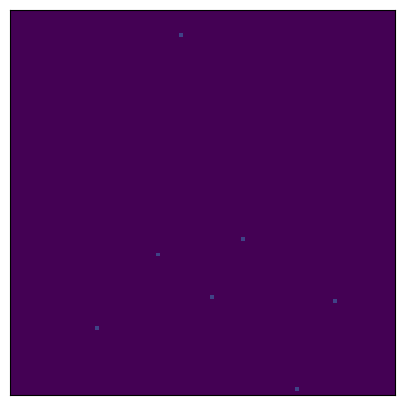

In [ ]:
'''
Show the target map, where transient is 1 and rest is 0
'''
plt.figure(figsize = (5,5))
plt.imshow((target_map),vmax = 5,vmin = 0)
plt.xticks([])
plt.yticks([])
plt.show()
plt.close()

In [ ]:
# generates and saves animation frames for the above generated field
for frame in range(100):
    plt.figure(figsize = (5,5))
    plt.imshow((bg+noise+transients)[:,:,6*frame],vmax = 5,vmin = 0)
    plt.xticks([])
    plt.yticks([])
    #plt.savefig('/Users/dtian/Documents/Programming/Di_Research/example_animation/frame_%d.png' %frame)
    #plt.show()
    plt.close()

In [ ]:
def genfields(Nfields=10, xlen=100, ylen=100, tlen=608, noiseamp=0.1, transient_toggle = True):
    '''
    Return: combined_field: Nfield * xlen * ylen * tlen, X input for NN
            target_maps:    Nfield * xlen * ylen, y for NN
            bgpositions:    Nfield * Nbgnd * 2, location of all background
            transientpositions: Nfield * Ntrans * 2, location of all transients

    '''
    combined_fields = np.empty((Nfields, xlen, ylen, tlen), dtype=np.float16)
    target_maps     = np.empty((Nfields, xlen, ylen),       dtype=np.float16)
    bgpositions, transientspositions = [], []

    for i in range(Nfields):
        print("Generating Image Index:", i)
        Nbgnd  = np.random.randint(1, 25)
        if(transient_toggle):
            Ntrans = np.random.randint(25)
        else: 
            Ntrans = 0
        bg, noise, bgposition = genbackground(xlen, ylen, tlen, Nbgnd, noiseamp)
        transient, tpos, target_map = gentransients(xlen, ylen, tlen, Ntrans)

        combined_fields[i] = bg + noise + transient   # written in place, float32
        target_maps[i]     = target_map
        bgpositions.append(bgposition)
        transientspositions.append(tpos)
    #bgpositions = np.array(bgpositions)
    #transientspositions = np.array(transientspositions)
    return combined_fields, target_maps, bgpositions, transientspositions

In [ ]:
'''
def normalize_data(data, eps=1e-8):
    mean = data.mean()
    std = data.std()
    data -= mean            # in-place, no new allocation
    data /= (std + eps)     # in-place, no new allocation
    return data, mean, std

def convert_to_torch_data(data):
    data = torch.from_numpy(data)          # no copy (shares numpy memory)
    data = data.squeeze(0)
    if data.dim() == 4:                    # NHWC -> NCHW
        data = data.permute(0, 3, 1, 2)    # view only — no copy, no .contiguous()
    data, mean, std = normalize_data(data) # now genuinely in-place
    return data, mean, std
'''

def normalize_np(data, sample_frac=0.05, eps=1e-8):
    """
    Computes mean/std from a random subsample of `data` (cheap, statistically
    sufficient at this dataset size), then normalizes `data` in-place.
    Runs entirely on the original contiguous numpy array -- no torch,
    no permute -- so there's no ambiguity about whether a reduction over
    a huge strided view silently materializes a full-size temporary.
    """
    n = data.shape[0]
    sample_size = max(1, int(n * sample_frac))
    idx = np.random.choice(n, size=sample_size, replace=False)
    sample = data[idx].astype(np.float32)   # small, bounded copy just for stats
    mean = sample.mean()
    std  = sample.std()
    del sample

    data -= mean            # in-place on the big contiguous array, no new allocation
    data /= (std + eps)     # in-place, no new allocation
    return data, mean, std

def to_torch_nchw(data):
    """Convert an already-normalized NHWC numpy array into an NCHW torch view."""
    data = torch.from_numpy(data)   # no copy, shares the (already normalized) numpy memory
    data = data.squeeze(0)
    if data.dim() == 4:
        data = data.permute(0, 3, 1, 2)   # view only -- normalization is already done
    return data

        

In [ ]:
X_start, y_start, _, _ = genfields(Nfields = 2)

Generating Image Index: 0
Generating Image Index: 1


In [ ]:
for frame in range(101):
    plt.figure(figsize = (5,5))
    plt.imshow((X_start[0])[:,:,6*frame],vmax = 5,vmin = 0)
    plt.xticks([])
    plt.yticks([])
    #plt.savefig('/Users/dtian/Documents/Programming/Di_Research/example_animation/frame_%d.png' %frame)
    #plt.show()
    plt.close()

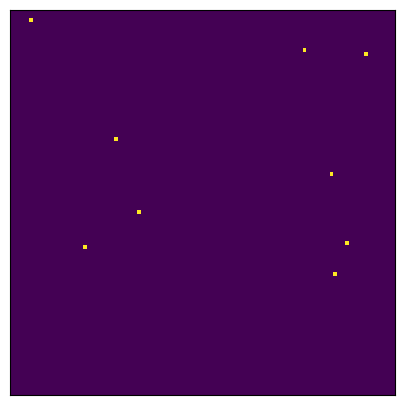

In [ ]:
plt.figure(figsize = (5,5))
plt.imshow((y_start[0]),vmax = 1,vmin = 0)
plt.xticks([])
plt.yticks([])
plt.show()
plt.close()

In [ ]:
def gaussianize_target(data, sigma=1):
    N, H, W = data.shape
    out = np.empty((N, H, W), dtype=np.float16)
    for i in range(N):
        out[i] = make_gaussian_heatmap(data[i], sigma)
    return out

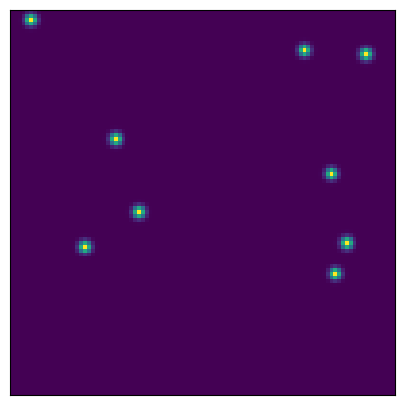

In [ ]:
y_start_gaussian = gaussianize_target(y_start, sigma=1)
plt.figure(figsize = (5,5))
plt.imshow((y_start_gaussian[0]),vmax = 1,vmin = 0)
plt.xticks([])
plt.yticks([])
plt.show()
plt.close()
#np.save(output_dir + "X_start.npy", X_start)

In [ ]:
'''
X_test, y_test, bgspositions_test, transientspositions_test= genfields(Nfields=6000)
print(X_test.shape)
print(y_test.shape)
print(bgspositions_test[1].shape)
print(transientspositions_test[1].shape)
np.save(output_dir + "X_test.npy", X_test)
np.save(output_dir + "y_test.npy", y_test) 
np.savez(output_dir + "bgspositions_test.npy", *bgspositions_test)
np.savez(output_dir + "transientspositions_test.npy", *transientspositions_test)

print("Test?")
X_train, y_train, bgspositions_train, transientspositions_train,= genfields(Nfields=30000)
print("X_train  nan:", np.isnan(X_train).any().item(),  "inf:", np.isinf(X_train).any().item())
print("y_train  nan:", np.isnan(y_train).any().item(),  "inf:", np.isinf(y_train).any().item())
print("X_test  nan:", np.isnan(X_test).any().item(),  "inf:", np.isinf(X_test).any().item())
print("y_test  nan:", np.isnan(y_test).any().item(),  "inf:", np.isinf(y_test).any().item())
np.save(output_dir + "X_train.npy", X_train)
np.save(output_dir + "y_train.npy", y_train)
np.savez(output_dir + "bgspositions_train.npy", *bgspositions_train)
np.savez(output_dir + "transientspositions_train.npy", *transientspositions_train)
'''

'\nX_test, y_test, bgspositions_test, transientspositions_test= genfields(Nfields=6000)\nprint(X_test.shape)\nprint(y_test.shape)\nprint(bgspositions_test[1].shape)\nprint(transientspositions_test[1].shape)\nnp.save(output_dir + "X_test.npy", X_test)\nnp.save(output_dir + "y_test.npy", y_test) \nnp.savez(output_dir + "bgspositions_test.npy", *bgspositions_test)\nnp.savez(output_dir + "transientspositions_test.npy", *transientspositions_test)\n\nprint("Test?")\nX_train, y_train, bgspositions_train, transientspositions_train,= genfields(Nfields=30000)\nprint("X_train  nan:", np.isnan(X_train).any().item(),  "inf:", np.isinf(X_train).any().item())\nprint("y_train  nan:", np.isnan(y_train).any().item(),  "inf:", np.isinf(y_train).any().item())\nprint("X_test  nan:", np.isnan(X_test).any().item(),  "inf:", np.isinf(X_test).any().item())\nprint("y_test  nan:", np.isnan(y_test).any().item(),  "inf:", np.isinf(y_test).any().item())\nnp.save(output_dir + "X_train.npy", X_train)\nnp.save(output_

In [ ]:
'''
print("Test?")
X_train, y_train, bgspositions_train, transientspositions_train,= genfields(Nfields=30000)
print("X_train  nan:", np.isnan(X_train).any().item(),  "inf:", np.isinf(X_train).any().item())
print("y_train  nan:", np.isnan(y_train).any().item(),  "inf:", np.isinf(y_train).any().item())
#print("X_test  nan:", np.isnan(X_test).any().item(),  "inf:", np.isinf(X_test).any().item())
#print("y_test  nan:", np.isnan(y_test).anyss().item(),  "inf:", np.isinf(y_test).any().item())
np.save(output_dir + "X_train.npy", X_train)
np.save(output_dir + "y_train.npy", y_train)
np.savez(output_dir + "bgspositions_train.npy", *bgspositions_train)
np.savez(output_dir + "transientspositions_train.npy", *transientspositions_train)
'''

'\nprint("Test?")\nX_train, y_train, bgspositions_train, transientspositions_train,= genfields(Nfields=30000)\nprint("X_train  nan:", np.isnan(X_train).any().item(),  "inf:", np.isinf(X_train).any().item())\nprint("y_train  nan:", np.isnan(y_train).any().item(),  "inf:", np.isinf(y_train).any().item())\n#print("X_test  nan:", np.isnan(X_test).any().item(),  "inf:", np.isinf(X_test).any().item())\n#print("y_test  nan:", np.isnan(y_test).anyss().item(),  "inf:", np.isinf(y_test).any().item())\nnp.save(output_dir + "X_train.npy", X_train)\nnp.save(output_dir + "y_train.npy", y_train)\nnp.savez(output_dir + "bgspositions_train.npy", *bgspositions_train)\nnp.savez(output_dir + "transientspositions_train.npy", *transientspositions_train)\n'

In [ ]:
'''
X_train = np.load(output_dir + "X_train.npy")
y_train = np.load(output_dir + "y_train.npy")
#bgspositions_train = np.load("bgspositions_train.npy")
#transientspositions_train = np.load("transientspositions_train.npy")
X_test = np.load(output_dir + "X_test.npy")
y_test = np.load(output_dir + "y_test.npy")
#bgspositions_test = np.load("bgspositions_test.npy")s
#transientspositions_test = np.load("transientspositions_test.npy")
'''

'\nX_train = np.load(output_dir + "X_train.npy")\ny_train = np.load(output_dir + "y_train.npy")\n#bgspositions_train = np.load("bgspositions_train.npy")\n#transientspositions_train = np.load("transientspositions_train.npy")\nX_test = np.load(output_dir + "X_test.npy")\ny_test = np.load(output_dir + "y_test.npy")\n#bgspositions_test = np.load("bgspositions_test.npy")s\n#transientspositions_test = np.load("transientspositions_test.npy")\n'

In [ ]:
X_test = np.load(output_dir + "X_test.npy")
y_test = np.load(output_dir + "y_test.npy")
X_test, x_test_mean, x_test_std = normalize_np(X_test)
X_test = to_torch_nchw(X_test)

y_test_gaussian = gaussianize_target(y_test, sigma=1)
y_test_gaussian, _, _ = normalize_np(y_test_gaussian)
y_test_gaussian = to_torch_nchw(y_test_gaussian)
print(X_test.shape)
print(y_test.shape)
print(y_test_gaussian.shape)

torch.Size([6000, 608, 100, 100])
(6000, 100, 100)
torch.Size([6000, 100, 100])


In [ ]:
X_train = np.load(output_dir + "X_train.npy")
print("X_train loaded Reached here?")
y_train = np.load(output_dir + "y_train.npy")
print("Reached here?")
X_train, x_train_mean, x_train_std = normalize_np(X_train)
print("Reached here?")
X_train = to_torch_nchw(X_train)
print("Reached here?")

y_train_gaussian = gaussianize_target(y_train, sigma=1)
y_train_gaussian, y_train_mean, y_train_std = normalize_np(y_train_gaussian)
y_train_gaussian = to_torch_nchw(y_train_gaussian)
print("Reached here?")
print("y_train_mean is", y_train_mean)
print("y_train_std is", y_train_std)
print(X_train.shape)
print(y_train.shape)
print(y_train_gaussian.shape)

X_train loaded Reached here?
Reached here?
Reached here?
Reached here?
Reached here?
y_train_mean is 0.0072316113
y_train_std is 0.0600101
torch.Size([30000, 608, 100, 100])
(30000, 100, 100)
torch.Size([30000, 100, 100])


In [ ]:
'''print(X_test.shape)
print(y_test.shape)
print(y_test_gaussian.shape)
print(X_train.shape)
print(y_train.shape)
print(y_train_gaussian.shape)
'''

'print(X_test.shape)\nprint(y_test.shape)\nprint(y_test_gaussian.shape)\nprint(X_train.shape)\nprint(y_train.shape)\nprint(y_train_gaussian.shape)\n'

In [ ]:
'''
X_test,_,_ = convert_to_torch_data(X_test)
y_test_gaussian = gaussianize_target(y_test, sigma=1)
y_test_gaussian,_,_ = convert_to_torch_data(y_test_gaussian)
print(X_test.shape)
print(y_test_gaussian.shape)
'''

'\nX_test,_,_ = convert_to_torch_data(X_test)\ny_test_gaussian = gaussianize_target(y_test, sigma=1)\ny_test_gaussian,_,_ = convert_to_torch_data(y_test_gaussian)\nprint(X_test.shape)\nprint(y_test_gaussian.shape)\n'

In [ ]:
'''
print("Reached here?")
X_train,_,_ = convert_to_torch_data(X_train)
print("Reached here?")
y_train_gaussian = gaussianize_target(y_train, sigma=1)
print("Reached here?")
y_train_gaussian,y_train_mean,y_train_std = convert_to_torch_data(y_train_gaussian)
#print(X_train.shape)
#print(y_train.shape)
print("y_train_mean is", y_train_mean)
print("y_train_std is", y_train_std)
'''

'\nprint("Reached here?")\nX_train,_,_ = convert_to_torch_data(X_train)\nprint("Reached here?")\ny_train_gaussian = gaussianize_target(y_train, sigma=1)\nprint("Reached here?")\ny_train_gaussian,y_train_mean,y_train_std = convert_to_torch_data(y_train_gaussian)\n#print(X_train.shape)\n#print(y_train.shape)\nprint("y_train_mean is", y_train_mean)\nprint("y_train_std is", y_train_std)\n'

In [ ]:
'''
print("X_train  nan:", torch.isnan(X_train).any().item(),  "inf:", torch.isinf(X_train).any().item())
print("y_train_gaussian  nan:", torch.isnan(y_train_gaussian).any().item(),  "inf:", torch.isinf(y_train_gaussian).any().item())
print("X_test  nan:", torch.isnan(X_test).any().item(),  "inf:", torch.isinf(X_test).any().item())
print("y_test_gaussian  nan:", torch.isnan(y_test_gaussian).any().item(),  "inf:", torch.isinf(y_test_gaussian).any().item())
'''

'\nprint("X_train  nan:", torch.isnan(X_train).any().item(),  "inf:", torch.isinf(X_train).any().item())\nprint("y_train_gaussian  nan:", torch.isnan(y_train_gaussian).any().item(),  "inf:", torch.isinf(y_train_gaussian).any().item())\nprint("X_test  nan:", torch.isnan(X_test).any().item(),  "inf:", torch.isinf(X_test).any().item())\nprint("y_test_gaussian  nan:", torch.isnan(y_test_gaussian).any().item(),  "inf:", torch.isinf(y_test_gaussian).any().item())\n'

In [ ]:

train_dataset = TensorDataset(X_train, y_train_gaussian)
test_dataset  = TensorDataset(X_test,  y_test_gaussian)

batch_size = 128

train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_dataloader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)


In [ ]:

class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(x + self.block(x))


class HeatmapNet(nn.Module):
    """
    Input:  (N, 608, 100, 100)
    Output: (N, 100, 100)
    """
    def __init__(self, tlen=608):
        super().__init__()
        self.enlarge1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)  # -> 200x200

        # Encode
        self.stem = nn.Sequential(
            nn.Conv2d(tlen, 96, 15, padding=7), nn.BatchNorm2d(96), nn.ReLU(),
        )                                                  # (N, 96, 200, 200)
        self.enc1  = nn.Sequential(ResBlock(96), ResBlock(96))
        self.down1 = nn.MaxPool2d(2)                       # -> 100x100

        self.enc2  = nn.Sequential(
            nn.Conv2d(96, 192, 3, padding=1), nn.BatchNorm2d(192), nn.ReLU(),
            ResBlock(192), ResBlock(192),
        )                                                  # (N, 192, 100, 100)
        self.down2 = nn.MaxPool2d(2)                       # -> 50x50

        self.enc3  = nn.Sequential(
            nn.Conv2d(192, 384, 3, padding=1), nn.BatchNorm2d(384), nn.ReLU(),  # FIX 1: in-channels 96 -> 192
            ResBlock(384), ResBlock(384),
        )                                                  # (N, 384, 50, 50)
        self.down3 = nn.MaxPool2d(2)                       # -> 25x25

        self.bottleneck = nn.Sequential(
            nn.Conv2d(384, 768, 3, padding=1), nn.BatchNorm2d(768), nn.ReLU(),
            ResBlock(768), ResBlock(768),
        )                                                  # (N, 768, 25, 25)

        # Decode
        self.up2  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)  # 25 -> 50
        self.dec2 = nn.Sequential(
            nn.Conv2d(768 + 384, 192, 3, padding=1), nn.BatchNorm2d(192), nn.ReLU(),   # in: 768(up)+384(e3 skip)=1152
            ResBlock(192),
        )
        self.up1  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)  # 50 -> 100
        self.dec1 = nn.Sequential(
            nn.Conv2d(192 + 192, 96, 3, padding=1), nn.BatchNorm2d(96), nn.ReLU(),      # FIX 4: 192+96 -> 192+192 (e2 skip has 192 ch)
            ResBlock(96),
        )

        self.head = nn.Conv2d(96, 1, 1)                    # 1-channel logits

    def forward(self, x):
        pre_enlarge = self.enlarge1(x)          # 200x200
        s  = self.stem(pre_enlarge)             # 200x200, 96
        e1 = self.enc1(s)                       # 200x200, 96
        e2 = self.enc2(self.down1(e1))          # 100x100, 192
        e3 = self.enc3(self.down2(e2))          # 50x50,  384
        b  = self.bottleneck(self.down3(e3))    # 25x25,  768   FIX 2: down2 -> down3

        d2 = self.dec2(torch.cat([self.up2(b),  e3], dim=1))  # 50x50   FIX 3: skip e2 -> e3
        d1 = self.dec1(torch.cat([self.up1(d2), e2], dim=1))  # 100x100 FIX 3: skip e1 -> e2
        return self.head(d1).squeeze(1)         # (N, 100, 100)


In [ ]:
'''
The hungarian_loss take account the fact that two similar transient 3D image, (A, B, C) and (B, A, C), would be similar but with differnent loss
Hungarian_loss take care of it and make them similar loss
'''

from scipy.optimize import linear_sum_assignment
import torch.nn.functional as F

def hungarian_loss(pred, target):
    # pred, target: (N, n_trans, n_params)
    batch_size, n_trans = pred.shape[:2]
    losses = []

    for i in range(batch_size):
        cost = torch.stack([
            torch.stack([F.mse_loss(pred[i, j], target[i, k])
                         for k in range(n_trans)])
            for j in range(n_trans)
        ])
        row_ind, col_ind = linear_sum_assignment(cost.detach().cpu().numpy())
        matched = cost[row_ind, col_ind].sum()   # advanced indexing, stays on GPU, keeps grad
        losses.append(matched / n_trans)

    return torch.stack(losses).mean()

In [ ]:
model = HeatmapNet().to(device)
model.to(torch.float16)
print(model)
loss_fn = hungarian_loss

HeatmapNet(
  (enlarge1): Upsample(scale_factor=2.0, mode='bilinear')
  (stem): Sequential(
    (0): Conv2d(608, 96, kernel_size=(15, 15), stride=(1, 1), padding=(7, 7))
    (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (enc1): Sequential(
    (0): ResBlock(
      (block): Sequential(
        (0): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (relu): ReLU()
    )
    (1): ResBlock(
      (block): Sequential(
        (0): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Con

In [ ]:
def train_loop(dataloader, model, loss_fn, optimizer):
    model.train()
    total_loss = 0
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()
    return total_loss / len(dataloader)


def test_loop(dataloader, model, loss_fn):
    model.eval()
    num_batches = len(dataloader)
    test_loss = 0
    all_preds = []

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            all_preds.append(pred)

    test_loss /= num_batches
    all_preds = torch.cat(all_preds, dim=0)
    return all_preds, test_loss  

In [ ]:
'''
X_small = X_train[:2].to(device)
y_small = y_train[:2].to(device)
print(X_small.shape)
print(y_small.shape)

model.train()
pred = model(X_small)
print("Forward:", pred.shape)
print(y_small)
print("X_train  nan:", torch.isnan(X_train).any().item(),  "inf:", torch.isinf(X_train).any().item())
print("y_train  nan:", torch.isnan(y_train_gaussian).any().item(),  "inf:", torch.isinf(y_train_gaussian).any().item())
print("X_test  nan:", torch.isnan(X_test).any().item(),  "inf:", torch.isinf(X_test).any().item())
print("y_test  nan:", torch.isnan(y_test_gaussian).any().item(),  "inf:", torch.isinf(y_test_gaussian).any().item())
print("pred  nan:", torch.isnan(pred).any().item(),  "inf:", torch.isinf(pred).any().item())
print("y     nan:", torch.isnan(y_small).any().item(), "inf:", torch.isinf(y_small).any().item())
loss = hungarian_loss(pred, y_small)
loss.backward()
print("Backward OK, loss:", loss.item())
'''

'\nX_small = X_train[:2].to(device)\ny_small = y_train[:2].to(device)\nprint(X_small.shape)\nprint(y_small.shape)\n\nmodel.train()\npred = model(X_small)\nprint("Forward:", pred.shape)\nprint(y_small)\nprint("X_train  nan:", torch.isnan(X_train).any().item(),  "inf:", torch.isinf(X_train).any().item())\nprint("y_train  nan:", torch.isnan(y_train_gaussian).any().item(),  "inf:", torch.isinf(y_train_gaussian).any().item())\nprint("X_test  nan:", torch.isnan(X_test).any().item(),  "inf:", torch.isinf(X_test).any().item())\nprint("y_test  nan:", torch.isnan(y_test_gaussian).any().item(),  "inf:", torch.isinf(y_test_gaussian).any().item())\nprint("pred  nan:", torch.isnan(pred).any().item(),  "inf:", torch.isinf(pred).any().item())\nprint("y     nan:", torch.isnan(y_small).any().item(), "inf:", torch.isinf(y_small).any().item())\nloss = hungarian_loss(pred, y_small)\nloss.backward()\nprint("Backward OK, loss:", loss.item())\n'

In [ ]:

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: torch.Size([30000, 608, 100, 100])
y_train shape: (30000, 100, 100)
X_test shape: torch.Size([6000, 608, 100, 100])


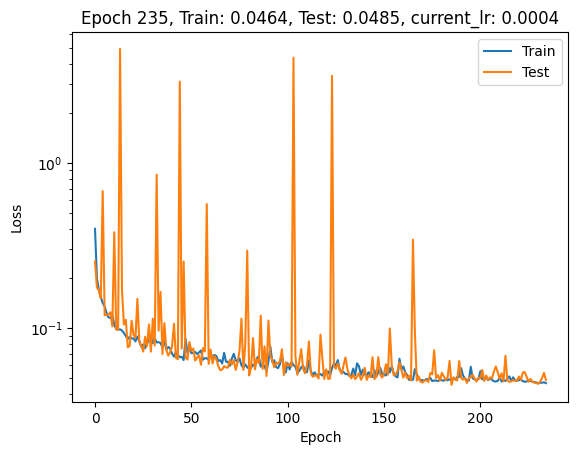

Early stopping at epoch 236. Best test loss 0.0453 at epoch 186.
Done!
weight saved!


In [ ]:
import copy
import matplotlib.pyplot as plt
from IPython.display import clear_output

learning_rate = 1e-3
max_epochs = 1000          # generous upper bound; early stopping ends it
patience = 50              # stop after this many epochs with no improvement
min_delta = 1e-4           # improvement smaller than this doesn't count

best_loss = float("inf")
wait = 0
best_state = None
best_epoch = 0

train_losses, test_losses = [], []

loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience = 20, factor=0.8)#, verbose=True)

for t in range(max_epochs):
    train_loss = train_loop(train_dataloader, model, loss_fn, optimizer)
    preds, test_loss = test_loop(test_dataloader, model, loss_fn)
    scheduler.step(test_loss)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    if test_loss < best_loss - min_delta:      # improved
        best_loss = test_loss
        best_epoch = t
        wait = 0
        best_state = copy.deepcopy(model.state_dict())   # snapshot best weights
        torch.save(best_state, output_dir + "best_weight.pth")       # also persist to disk
    else:                                        # no improvement
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {t+1}. "
                  f"Best test loss {best_loss:.4f} at epoch {best_epoch+1}.")
            break
    current_lr = optimizer.param_groups[0]['lr']
    clear_output(wait=True)
    plt.clf() 
    plt.plot(train_losses, label='Train')
    plt.plot(test_losses, label='Test')
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Epoch {t+1}, Train: {train_loss:.4f}, Test: {test_loss:.4f}, current_lr: {current_lr:.4f}')
    plt.legend()
    plt.show()
# restore the best weights (not the last, possibly-overfit ones)
if best_state is not None:
    model.load_state_dict(best_state)
print("Done!")
torch.save(model.state_dict(), output_dir + "last_weight.pth")
print("weight saved!")
